# Feature Engineering : Préparation pour le Machine Learning

Ce notebook prend le fichier  et le transforme en , prêt à être ingéré par des modèles prédictifs (XGBoost, Random Forest, Régression Linéaire).

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Configuration
pd.set_option("display.max_columns", None)

print("Libraries chargées avec succès.")
import re
from sklearn.feature_extraction.text import TfidfVectorizer


Libraries chargées avec succès.


## 1. Chargement des données propres

In [27]:
df = pd.read_csv("../data/clean_data.csv")
print(f"Dimensions: {df.shape[0]} lignes, {df.shape[1]} colonnes.")
df.head(3)

Dimensions: 56697 lignes, 36 colonnes.


,id,title,description,publishedAt,duration,channelId,tags,topics,views,likes,comments,thumbnails,date,channel_id,channel_name,subscriber_count,creator_tier,total_videos,shorts_count_sample,avg_views,median_views,std_views,max_views,avg_like_rate,avg_duration_sec,pct_vertical,pct_has_music,avg_title_length,avg_hook_count,avg_emoji_count,pct_has_hashtag,viral_video_rate,views_per_subscriber,consistency_score,duration_sec,virality_score
0,4cdJzQWWkE0,"33.87 Seconds! Tru-Dad Solve 🤣 Clock R1,S2 OOC...",Visit @SpeedCubeShopOfficial and use code TRU ...,2026-03-12 06:00:02+00:00,PT1M4S,UCVnG-v6mxUHOB0i5cMUKnng,[],[],770.0,23.0,2.0,https://i.ytimg.com/vi/4cdJzQWWkE0/default.jpg,2026-03-12T11:24:15.230928Z,UCVnG-v6mxUHOB0i5cMUKnng,Tru Cubing,493000.0,mid,30.0,30.0,12737.97,10000.0,8625.71,35000.0,0.0,0.0,0.0,0.0,95.53,0.2333,0.1667,1.0,0.0,0.0258,0.5962,64.0,8.567300
1,7jdDyK-cbzQ,"3.87 Seconds! 2x2 Finals, S3 OOC '26 #shorts #...",Visit @SpeedCubeShopOfficial and use code TRU ...,2026-03-11 22:00:14+00:00,PT25S,UCVnG-v6mxUHOB0i5cMUKnng,[],[],5590.0,127.0,9.0,https://i.ytimg.com/vi/7jdDyK-cbzQ/default.jpg,2026-03-12T11:24:15.230928Z,UCVnG-v6mxUHOB0i5cMUKnng,Tru Cubing,493000.0,mid,30.0,30.0,12737.97,10000.0,8625.71,35000.0,0.0,0.0,0.0,0.0,95.53,0.2333,0.1667,1.0,0.0,0.0258,0.5962,25.0,6.419804
2,mqOwORyR5uE,"4.18 Seconds! 2x2 Finals, S2 - OOC '26 #youtub...",Visit @SpeedCubeShopOfficial and use code TRU ...,2026-03-11 14:01:11+00:00,PT29S,UCVnG-v6mxUHOB0i5cMUKnng,[],[],10733.0,231.0,8.0,https://i.ytimg.com/vi/mqOwORyR5uE/default.jpg,2026-03-12T11:24:15.230928Z,UCVnG-v6mxUHOB0i5cMUKnng,Tru Cubing,493000.0,mid,30.0,30.0,12737.97,10000.0,8625.71,35000.0,0.0,0.0,0.0,0.0,95.53,0.2333,0.1667,1.0,0.0,0.0258,0.5962,29.0,5.875860


## 1.5. Extraction de Caractéristiques (NLP sur la Description)
On extrait d'abord des **métriques structurelles** : la longueur, les hashtags, les liens...

In [28]:
# Fonctions de calcul NLP
def count_links(text):
    return len(re.findall(r'http[s]?://', str(text)))

def count_hashtags(text):
    return len(re.findall(r'#(\w+)', str(text)))

def shouting_ratio(text):
    text_str = str(text)
    if len(text_str) == 0: return 0
    return sum(1 for c in text_str if c.isupper()) / len(text_str)

df['desc_length'] = df['description'].fillna('').apply(lambda x: len(str(x)))
df['desc_num_hashtags'] = df['description'].fillna('').apply(count_hashtags)
df['desc_has_links'] = df['description'].fillna('').apply(count_links)
df['desc_shouting_ratio'] = df['description'].fillna('').apply(shouting_ratio)

print("Métriques structurelles ajoutées !")
df[['description', 'desc_length', 'desc_num_hashtags', 'desc_has_links']].head(3)

Métriques structurelles ajoutées !


,description,desc_length,desc_num_hashtags,desc_has_links
0,Visit @SpeedCubeShopOfficial and use code TRU ...,1807,158,0
1,Visit @SpeedCubeShopOfficial and use code TRU ...,1824,158,0
2,Visit @SpeedCubeShopOfficial and use code TRU ...,1819,158,0


Ensuite, on utilise **TF-IDF** pour trouver les 50 mots les plus discriminants (mots-clés).

In [29]:
# On remplace les NaN par du texte vide ou notre token
texts = df['description'].fillna('')

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=50, stop_words='english')
tfidf_matrix = tfidf.fit_transform(texts)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=[f"word_{w}" for w in tfidf.get_feature_names_out()])

# On ajoute ces 50 colonnes au DataFrame principal
df = pd.concat([df, tfidf_df], axis=1)

print(f"{tfidf_df.shape[1]} Mots-clés extraits via TF-IDF !")
print("Exemple de mots :", list(tfidf_df.columns)[:10])

50 Mots-clés extraits via TF-IDF !
Exemple de mots : ['word_amzn', 'word_arc', 'word_badminton', 'word_beat', 'word_beats', 'word_best', 'word_bowling', 'word_cartoon', 'word_channel', 'word_com']


## 2. Sélection des Variables (Feature Selection)
On retire les identifiants textuels (qui ne servent à rien pour l'algorithme) et les variables temporelles brutes.

In [30]:
# 2. Sélection des Variables (Feature Selection)
cols_to_drop = [
    # Identifiants textuels inutiles pour l'algorithme
    "id", "title", "description", "publishedAt", 
    "channelId", "channel_id", "channel_name", 
    "date", "thumbnails", "tags", "topics", "duration",
    # Constantes mathématiques vides (Zero-Variance Features)
    "avg_like_rate", "avg_duration_sec", "pct_vertical", 
    "pct_has_music", "viral_video_rate", "consistency_score"
]

# On garde df_features pour l'entraînement pur
df_features = df.drop(columns=cols_to_drop, errors="ignore")

print(f"Colonnes conservées pour l'apprentissage : {df_features.shape[1]}")
list(df_features.columns)


Colonnes conservées pour l'apprentissage : 72


['views',
 'likes',
 'comments',
 'subscriber_count',
 'creator_tier',
 'total_videos',
 'shorts_count_sample',
 'avg_views',
 'median_views',
 'std_views',
 'max_views',
 'avg_title_length',
 'avg_hook_count',
 'avg_emoji_count',
 'pct_has_hashtag',
 'views_per_subscriber',
 'duration_sec',
 'virality_score',
 'desc_length',
 'desc_num_hashtags',
 'desc_has_links',
 'desc_shouting_ratio',
 'word_amzn',
 'word_arc',
 'word_badminton',
 'word_beat',
 'word_beats',
 'word_best',
 'word_bowling',
 'word_cartoon',
 'word_channel',
 'word_com',
 'word_cricket',
 'word_cube',
 'word_cubing',
 'word_fast',
 'word_flags',
 'word_gta5',
 'word_hindi',
 'word_https',
 'word_india',
 'word_instagram',
 'word_kaise',
 'word_like',
 'word_magic',
 'word_no_description',
 'word_puzzle',
 'word_pyraminx',
 'word_raiders',
 'word_rpf',
 'word_rubik',
 'word_rubiks',
 'word_rubikscube',
 'word_seconds',
 'word_short',
 'word_shorts',
 'word_solve',
 'word_solving',
 'word_subscribe',
 'word_tiktok',
 '

## 3. Encodage des Variables Catégoriques
L'algorithme ne comprend que les chiffres. Si nous avons des catégories (comme le ), il faut les transformer en 0, 1, 2, etc.

In [31]:
# Vérifions s'il y a des colonnes non numériques
categorical_cols = df_features.select_dtypes(include=["object"]).columns
print("Colonnes nécessitant un encodage :", list(categorical_cols))

# Si creator_tier est présent, on peut faire un One-Hot Encoding ou un Label Encoding
if "creator_tier" in categorical_cols:
    # Get Dummies convertit "Bronze", "Gold" en colonnes tier_Bronze (0/1), tier_Gold (0/1)
    df_features = pd.get_dummies(df_features, columns=["creator_tier"], drop_first=True)
    print("creator_tier encodé avec succès.")

df_features.head()

Colonnes nécessitant un encodage : ['creator_tier']
creator_tier encodé avec succès.


/var/folders/32/gl897mz17tv8kwkkm7t67vc80000gn/T/ipykernel_73032/554373436.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_features.select_dtypes(include=["object"]).columns


,views,likes,comments,subscriber_count,total_videos,shorts_count_sample,avg_views,median_views,std_views,max_views,avg_title_length,avg_hook_count,avg_emoji_count,pct_has_hashtag,views_per_subscriber,duration_sec,virality_score,desc_length,desc_num_hashtags,desc_has_links,desc_shouting_ratio,word_amzn,word_arc,word_badminton,word_beat,word_beats,word_best,word_bowling,word_cartoon,word_channel,word_com,word_cricket,word_cube,word_cubing,word_fast,word_flags,word_gta5,word_hindi,word_https,word_india,word_instagram,word_kaise,word_like,word_magic,word_no_description,word_puzzle,word_pyraminx,word_raiders,word_rpf,word_rubik,word_rubiks,word_rubikscube,word_seconds,word_short,word_shorts,word_solve,word_solving,word_subscribe,word_tiktok,word_training,word_trending,word_trick,word_tricks,word_unboxing,word_upsc,word_video,word_viral,word_world,word_www,word_youtube,word_youtubeshorts,creator_tier_micro,creator_tier_mid,creator_tier_nano
0,770.0,23.0,2.0,493000.0,30.0,30.0,12737.97,10000.0,8625.71,35000.0,95.53,0.2333,0.1667,1.0,0.0258,64.0,8.567300,1807,158,0,0.016602,0.0,0.0,0.0,0.0,0.0,0.211897,0.0,0.0,0.0,0.113079,0.0,0.108383,0.266257,0.232279,0.0,0.0,0.0,0.0,0.0,0.109909,0.0,0.22229,0.0,0.0,0.244011,0.129221,0.0,0.0,0.0,0.0,0.0,0.434979,0.0,0.074825,0.449918,0.0,0.300618,0.113499,0.0,0.215058,0.0,0.0,0.0,0.0,0.092695,0.192645,0.222351,0.121264,0.0,0.106789,False,True,False
1,5590.0,127.0,9.0,493000.0,30.0,30.0,12737.97,10000.0,8625.71,35000.0,95.53,0.2333,0.1667,1.0,0.0258,25.0,6.419804,1824,158,0,0.017544,0.0,0.0,0.0,0.0,0.0,0.150394,0.0,0.0,0.0,0.080258,0.0,0.076925,0.188976,0.164860,0.0,0.0,0.0,0.0,0.0,0.078008,0.0,0.15777,0.0,0.0,0.173187,0.091715,0.0,0.0,0.0,0.0,0.0,0.617454,0.0,0.053107,0.558827,0.0,0.213364,0.080556,0.0,0.152638,0.0,0.0,0.0,0.0,0.065790,0.136730,0.157814,0.086067,0.0,0.075793,False,True,False
2,10733.0,231.0,8.0,493000.0,30.0,30.0,12737.97,10000.0,8625.71,35000.0,95.53,0.2333,0.1667,1.0,0.0258,29.0,5.875860,1819,158,0,0.017592,0.0,0.0,0.0,0.0,0.0,0.150394,0.0,0.0,0.0,0.080258,0.0,0.076925,0.188976,0.164860,0.0,0.0,0.0,0.0,0.0,0.078008,0.0,0.15777,0.0,0.0,0.173187,0.091715,0.0,0.0,0.0,0.0,0.0,0.617454,0.0,0.053107,0.558827,0.0,0.213364,0.080556,0.0,0.152638,0.0,0.0,0.0,0.0,0.065790,0.136730,0.157814,0.086067,0.0,0.075793,False,True,False
3,5896.0,189.0,5.0,493000.0,30.0,30.0,12737.97,10000.0,8625.71,35000.0,95.53,0.2333,0.1667,1.0,0.0258,77.0,8.682383,1801,158,0,0.016657,0.0,0.0,0.0,0.0,0.0,0.211897,0.0,0.0,0.0,0.113079,0.0,0.108383,0.266257,0.232279,0.0,0.0,0.0,0.0,0.0,0.109909,0.0,0.22229,0.0,0.0,0.244011,0.129221,0.0,0.0,0.0,0.0,0.0,0.434979,0.0,0.074825,0.449918,0.0,0.300618,0.113499,0.0,0.215058,0.0,0.0,0.0,0.0,0.092695,0.192645,0.222351,0.121264,0.0,0.106789,False,True,False
4,9959.0,264.0,5.0,493000.0,30.0,30.0,12737.97,10000.0,8625.71,35000.0,95.53,0.2333,0.1667,1.0,0.0258,36.0,7.127402,1814,158,0,0.017641,0.0,0.0,0.0,0.0,0.0,0.150394,0.0,0.0,0.0,0.080258,0.0,0.076925,0.188976,0.164860,0.0,0.0,0.0,0.0,0.0,0.078008,0.0,0.15777,0.0,0.0,0.173187,0.091715,0.0,0.0,0.0,0.0,0.0,0.617454,0.0,0.053107,0.558827,0.0,0.213364,0.080556,0.0,0.152638,0.0,0.0,0.0,0.0,0.065790,0.136730,0.157814,0.086067,0.0,0.075793,False,True,False


## 4. Nettoyage des fuites de données (Data Leakage)
**ATTENTION CRITIQUE** : La variable cible  a été calculée mathématiquement à partir de , , et .
Si on laisse  et  dans les variables d'entraînement, l'algorithme va "tricher" à 100% en devinant la formule ! Seule compte la capacité à prédire la viralité A PARTIR des attributs de la vidéo (titre long, émoticônes, âge de la chaîne...), et non à partir de ses performances futures.

In [32]:
leakage_cols = ["views", "likes", "comments", "views_per_subscriber"]
df_ml = df_features.drop(columns=[col for col in leakage_cols if col in df_features.columns])

print(f"Attributs prédictifs finaux ({df_ml.shape[1]} colonnes) :")
print(list(df_ml.columns))

Attributs prédictifs finaux (70 colonnes) :
['subscriber_count', 'total_videos', 'shorts_count_sample', 'avg_views', 'median_views', 'std_views', 'max_views', 'avg_title_length', 'avg_hook_count', 'avg_emoji_count', 'pct_has_hashtag', 'duration_sec', 'virality_score', 'desc_length', 'desc_num_hashtags', 'desc_has_links', 'desc_shouting_ratio', 'word_amzn', 'word_arc', 'word_badminton', 'word_beat', 'word_beats', 'word_best', 'word_bowling', 'word_cartoon', 'word_channel', 'word_com', 'word_cricket', 'word_cube', 'word_cubing', 'word_fast', 'word_flags', 'word_gta5', 'word_hindi', 'word_https', 'word_india', 'word_instagram', 'word_kaise', 'word_like', 'word_magic', 'word_no_description', 'word_puzzle', 'word_pyraminx', 'word_raiders', 'word_rpf', 'word_rubik', 'word_rubiks', 'word_rubikscube', 'word_seconds', 'word_short', 'word_shorts', 'word_solve', 'word_solving', 'word_subscribe', 'word_tiktok', 'word_training', 'word_trending', 'word_trick', 'word_tricks', 'word_unboxing', 'word_u

## 5. Corrélation avec la Target
Regardons quelles sont les variables qui influencent le plus le score de viralité !

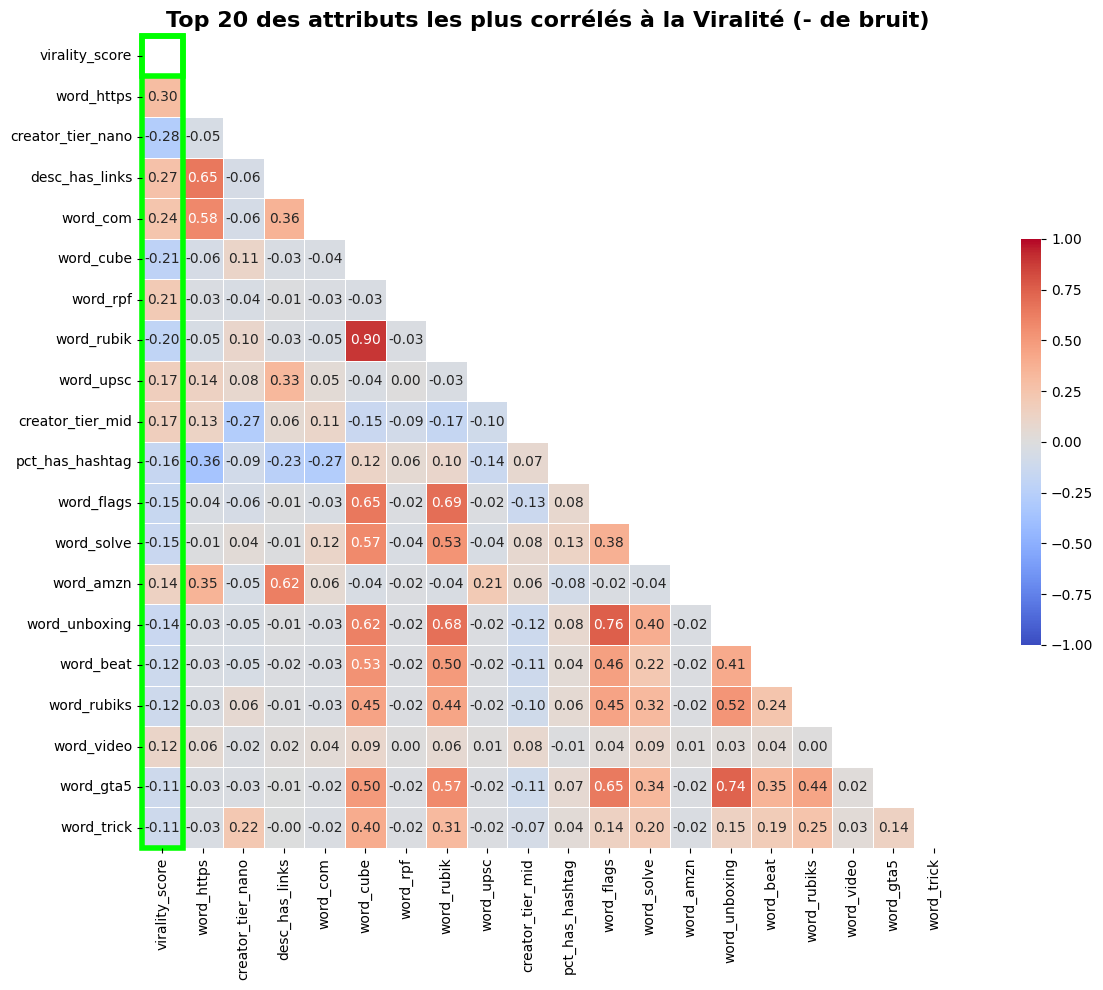

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import numpy as np

plt.figure(figsize=(14, 10))

# 1. Calcul de la matrice de corrélation complète
corr_matrix = df_ml.corr()

# 2. Sélection des 20 variables les plus corrélées (en absolu) avec le virality_score
# Cela nettoie le graphique en retirant le 'bruit' (les 40 mots-clés TF-IDF qui ont 0.00 de corrélation)
top_features = corr_matrix['virality_score'].abs().sort_values(ascending=False).head(20).index
corr_matrix_top = df_ml[top_features].corr()

# 3. Masque pour cacher la moitié supérieure
mask = np.triu(np.ones_like(corr_matrix_top, dtype=bool))

# Heatmap seaborn de la matrice filtrée
ax = sns.heatmap(corr_matrix_top, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", 
                 vmax=1, vmin=-1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})

# --- HIGHLIGHT DU SCORE DE VIRALITÉ ---
if 'virality_score' in corr_matrix_top.columns:
    target_idx = corr_matrix_top.columns.get_loc("virality_score")
    ax.add_patch(patches.Rectangle((0, target_idx), target_idx + 1, 1, fill=False, edgecolor='lime', lw=4, clip_on=False))
    ax.add_patch(patches.Rectangle((target_idx, target_idx), 1, len(corr_matrix_top) - target_idx, fill=False, edgecolor='lime', lw=4, clip_on=False))

plt.title("Top 20 des attributs les plus corrélés à la Viralité (- de bruit)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Sauvegarde des Features
Les données sont prêtes à être envoyées à Scikit-Learn ou XGBoost.

In [34]:
df_ml.to_csv("../data/features.csv", index=False)
print("Fichier features.csv sauvegardé avec succès dans le dossier data ! ")

Fichier features.csv sauvegardé avec succès dans le dossier data ! 
